In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import src.graph_utils as gutils

# Grape
from grape import Graph
from grape import GraphVisualizer

/media/data/mausoto/envs/hetnode2vec/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Erdos-Renyi

In [2]:
er_edges, er_nodes = gutils.generate_erdos_renyi_graph(n=50,p=0.7)

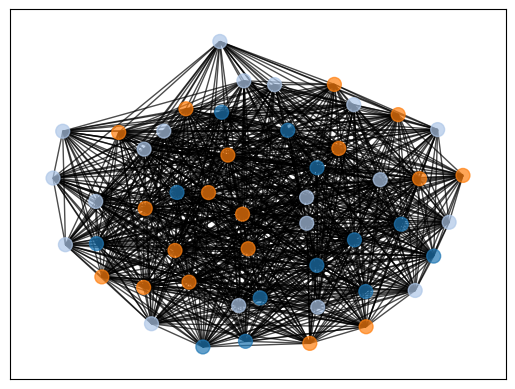

In [3]:
G_er = gutils.plot_graph(er_nodes,er_edges)

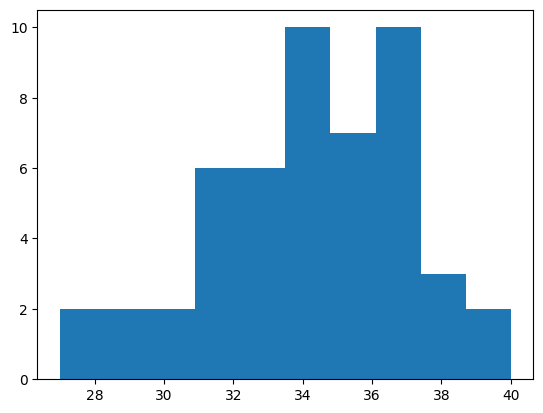

In [4]:
_ = plt.hist([G_er.degree(n) for n in G_er.nodes()])

### Converting to grape graph

In [5]:
edges_df = er_edges
nodes_df = er_nodes

# load it into a graph
G_er_grape = Graph.from_pd(
    edges_df=edges_df,
    nodes_df=nodes_df,
    node_name_column="name",
    node_type_column="type",
    edge_src_column="source",
    edge_dst_column="target",
    #edge_weight_column="weight",
    #edge_type_column="predicate",
    node_types_separator="|",
    directed=False,
    #name="tree",
)

In [6]:
G_er_grape

<div class="graph-report"><style>.graph-report li {margin: 0.5em 0 0.5em 0;}.graph-report .paragraph {text-align: justify;word-break: break-all;}.graph-report .small-columns {column-count: 4;column-gap: 2em;}.graph-report .medium-columns {column-count: 3;column-gap: 2em;}.graph-report .large-columns {column-count: 2;column-gap: 2em;}.graph-report .single-column {}@media only screen and (max-width: 600px) {.graph-report .small-columns {column-count: 1;}.graph-report .medium-columns {column-count: 1;}.graph-report .large-columns {column-count: 1;}}@media only screen and (min-width: 600px) and (max-width: 800px) {.graph-report .small-columns {column-count: 2;}.graph-report .medium-columns {column-count: 1;}.graph-report .large-columns {column-count: 1;}}@media only screen and (min-width: 800px) and (max-width: 1024px) {.graph-report .small-columns {column-count: 3;}.graph-report .medium-columns {column-count: 2;}.graph-report .large-columns {column-count: 1;}}</style><p class="paragraph">The undirected graph has 50 heterogeneous nodes and 857 edges. The graph is connected, that is, it is composed of a single connected component that includes all nodes and edges. The RAM requirements for the nodes and edges data structures are 2.88KB and 7.34KB respectively.</p><h3 style="margin: 1em 0 0 0;">Degree centrality</h3><p class="paragraph">The minimum node degree is 27, the maximum node degree is 40, the mode degree is 37, the mean degree is 34.28 and the node degree median is 34.</p><p class="paragraph">The nodes with the highest degree centrality are 45 (degree 40 and node type 2), 11 (degree 39 and node type 1), 15 (degree 38 and node type 2), 30 (degree 38 and node type 1) and 3 (degree 38 and node type 0).</p><h3 style="margin: 1em 0 0 0;">Node types</h3><p class="paragraph">The graph has 3 node types, which are 0 (19 nodes, 38.00%), 1 (18 nodes, 36.00%) and 2 (13 nodes, 26.00%). The RAM requirement for the node types data structure is 3.52KB.</p><h3 style="margin: 1em 0 0 0;">Topological Oddities</h3><p class="paragraph">A topological oddity is a set of nodes in the graph that <i>may be derived</i> by an error during the generation of the edge list of the graph and, depending on the task, could bias the results of topology-based models. In the following paragraph, we will describe the detected topological oddities.</p><h4 style="margin: 1em 0 0 0;">Isomorphic edge groups</h4><p class="paragraph">Isomorphic edge groups are edges with exactly the same neighbours, node types, edge types and weights (if present in the graph). Edges in such groups are topologically indistinguishable, that is swapping their ID would not change the graph topology. We have detected 2 isomorphic edge groups in the graph, involving a total of 8 nodes (16.00%) and 298 edges (17.39%). The detected isomorphic edge groups, sorted by decreasing size, are:</p><ol class="medium-columns"><li><p class="paragraph">Group with 2 edges (source degree 37 and node type 0, destination degree 40 and node type 2): (6 -> 45) and (3 -> 29).</p></li>
<li><p class="paragraph">Group with 2 edges (source degree 38 and node type 0, destination degree 34 and node type 1): (3 -> 17) and (18 -> 24).</p></li></ol></div>

## Power-Law graph

In [7]:
# THE DEGREE GENERATOR MUST BE INSTALLED!
# First we generate a degree distribution 
# using the generator described in 
#    https://www-complexnetworks.lip6.fr/~latapy/FV/generation.html
#    The method assume the existence of a file containing the adjacency list  

# Example a power law \alpha=2.1 with 1000 nodes with max degree 800, min degree 5, and average 6
! gengraph/bin/distrib 1000 2.1 1 800 6 > degs ;  gengraph/bin/graph degs > pwl_graph

double free or corruption (out)


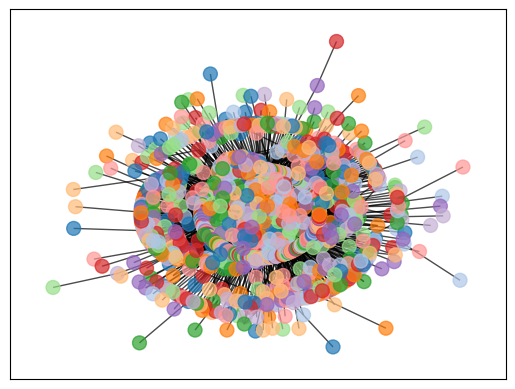

In [8]:
pwl_edges, pwl_nodes = gutils.generate_power_law_from_file(adjacency_list_file='pwl_graph')
G_pwl = gutils.plot_graph(pwl_nodes,pwl_edges)

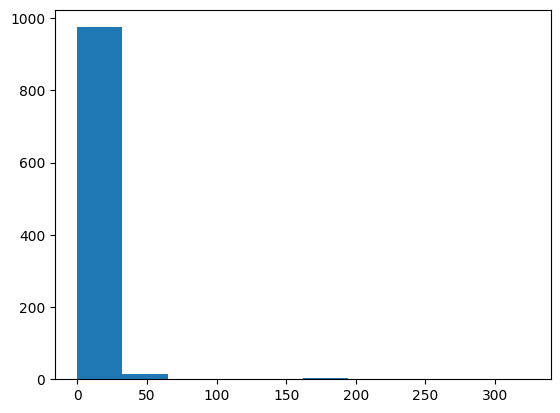

In [9]:
_ = plt.hist([G_pwl.degree(n) for n in G_pwl.nodes()])

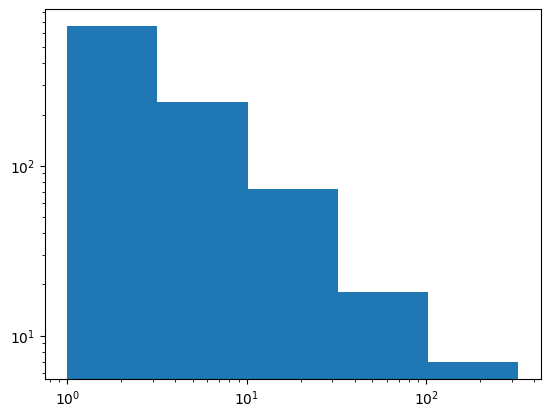

In [10]:
_ = gutils.plot_loghist([G_pwl.degree(n)+1 for n in G_pwl.nodes()], 5)

## Scale free - Preferential attachment

Reference: A. L. Barabási and R. Albert “Emergence of scaling in random networks”, Science 286, pp 509-512, 1999.

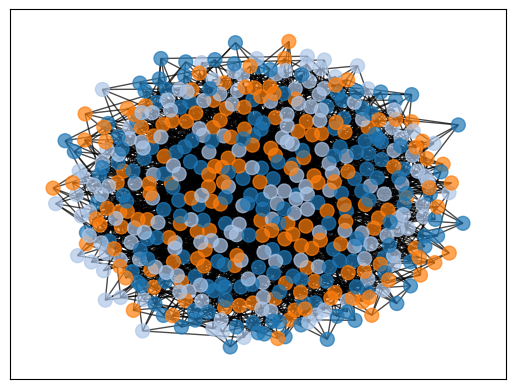

In [11]:
ba_edges, ba_nodes = gutils.generate_babarasi_albert(n=500, m=5, num_node_types=3)
G_ba = gutils.plot_graph(ba_nodes,ba_edges)

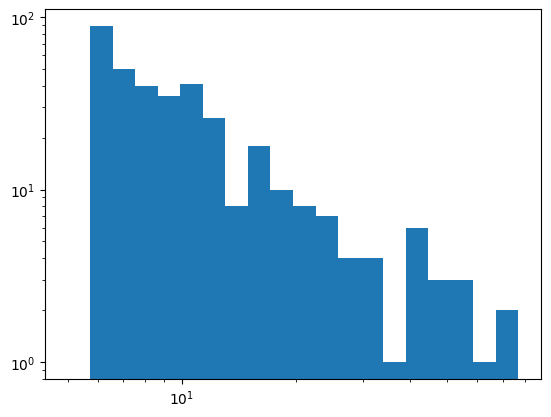

In [12]:
_ = gutils.plot_loghist([G_ba.degree(n) for n in G_ba.nodes()], 20)

## Grid graph

In [13]:
grid_edges, grid_nodes = gutils.generate_grid(rows=20,columns=15)

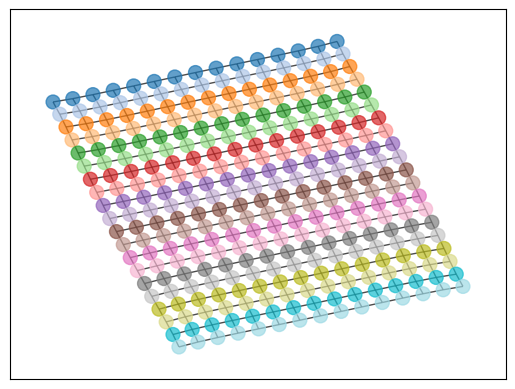

In [14]:
G_grid = gutils.plot_graph(grid_nodes,grid_edges)

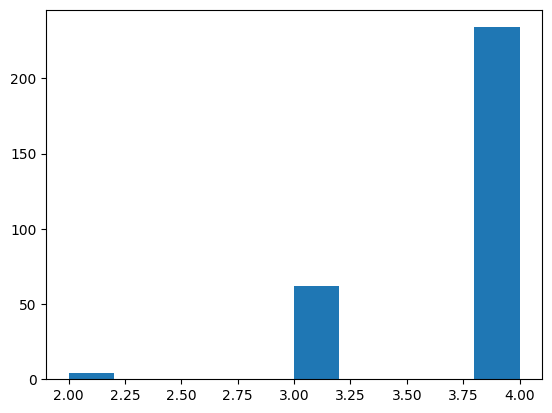

In [15]:
_ = plt.hist([G_grid.degree(n) for n in G_grid.nodes()])

# Clustered Grid

In [16]:
cl_grid_edges, cl_grid_nodes = gutils.generate_clustered_grid(rows=20,columns=10,groups=5)

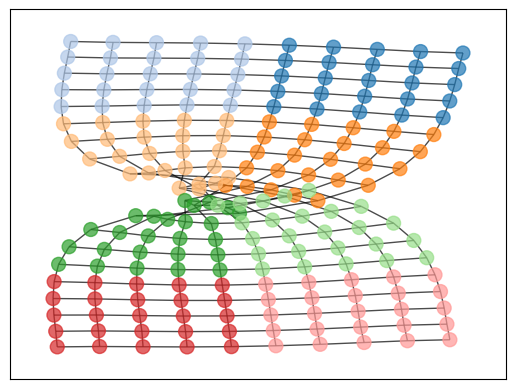

In [17]:
G_clustered_grid = gutils.plot_graph(cl_grid_nodes,cl_grid_edges)

# Cycle 

In [18]:
cycle_edges, cycle_nodes = gutils.generate_cycle(n=20,n_types=4)

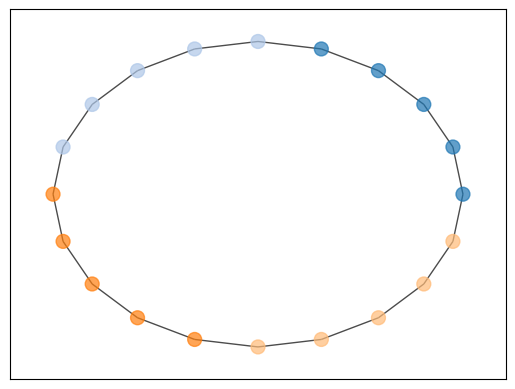

In [19]:
G_cycle = gutils.plot_graph(cycle_nodes,cycle_edges)

# Complete Bipartite

In [20]:
bip_edges, bip_nodes = gutils.generate_complete_bipartite(n1=5,n2=10)

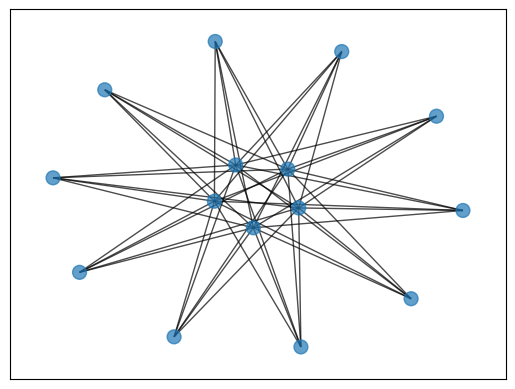

In [21]:
G_bip = gutils.plot_graph(bip_nodes,bip_edges)

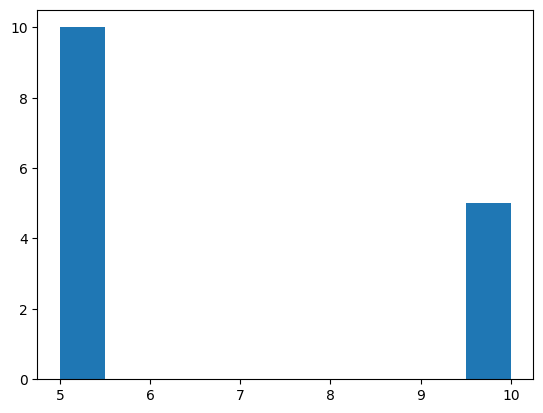

In [22]:
_ = plt.hist([G_bip.degree(n) for n in G_bip.nodes()])

# Complete graph

In [23]:
Kn_edges, Kn_nodes = gutils.generate_complete_graph(n=15,k=5)

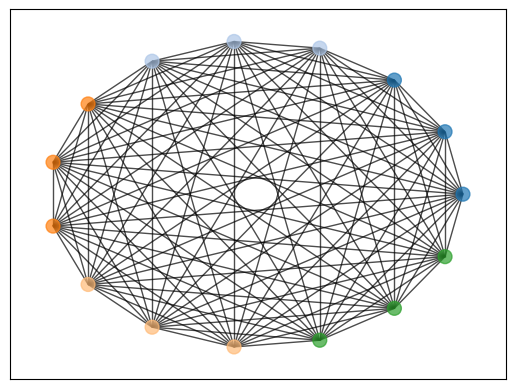

In [24]:
G_Kn = gutils.plot_graph(Kn_nodes,Kn_edges)

# Clustered graph

In [26]:
comm_edges, comm_nodes = gutils.generate_community_graph(
    k=5,              # Number of communities
    min_size=5,       # Minimum community size
    max_size=50,      # Maximum community size
    intra_prob=0.7,   # High probability within communities (dense)
    inter_prob=0.002,  # Low probability between communities (sparse)
    seed=42
)


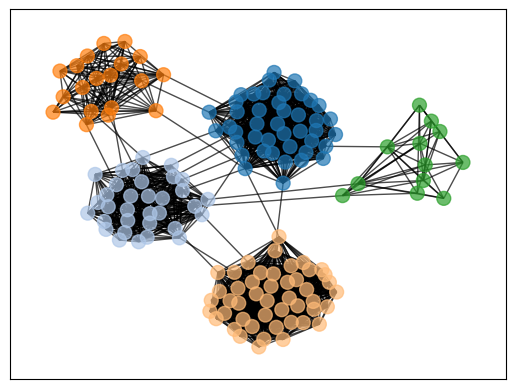

In [27]:
G_comm = gutils.plot_graph(comm_nodes, comm_edges)

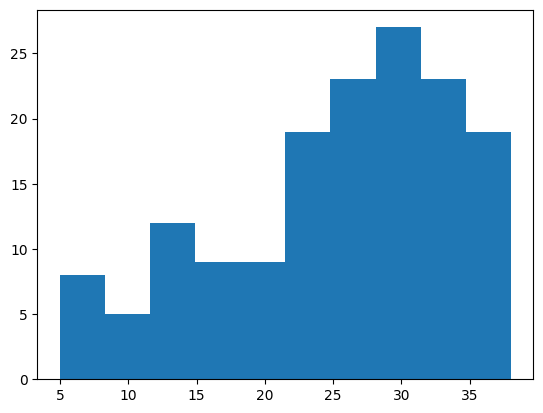

In [28]:
_ = plt.hist([G_comm.degree(n) for n in G_comm.nodes()])

# Tree

In [29]:
tree_edges, tree_nodes = gutils.generate_regular_tree(tree_depth=4,degree=3)

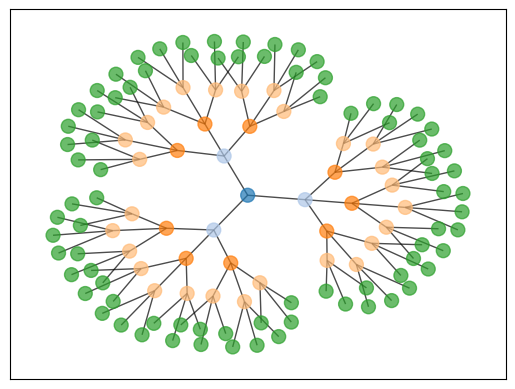

In [30]:
G_tree = gutils.plot_graph(tree_nodes, tree_edges)